In [1]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

# =========================
# LOAD DATASET (UCI - Iris)
# =========================
data = load_iris()
X = data.data

# =========================
# PREPROCESSING METHODS
# =========================
def preprocess_data(X, method):
    if method == "none":
        return X
    elif method == "normalize":
        return StandardScaler().fit_transform(X)
    elif method == "pca":
        return PCA(n_components=2).fit_transform(X)
    elif method == "normalize+pca":
        X_scaled = StandardScaler().fit_transform(X)
        return PCA(n_components=2).fit_transform(X_scaled)

# =========================
# EVALUATION FUNCTION
# =========================
def evaluate(X, labels):
    # Avoid invalid clustering
    if len(set(labels)) <= 1:
        return None, None, None

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    return sil, ch, db

# =========================
# MAIN EXPERIMENT LOOP
# =========================
cluster_range = [3, 4, 5]
preprocessing_methods = ["none", "normalize", "pca", "normalize+pca"]

results = []

for prep in preprocessing_methods:
    X_processed = preprocess_data(X, prep)

    for k in cluster_range:

        # ----- KMEANS -----
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X_processed)
        sil, ch, db = evaluate(X_processed, labels)

        results.append(["KMeans", prep, k, sil, ch, db])

        # ----- HIERARCHICAL -----
        hierarchical = AgglomerativeClustering(n_clusters=k)
        labels = hierarchical.fit_predict(X_processed)
        sil, ch, db = evaluate(X_processed, labels)

        results.append(["Hierarchical", prep, k, sil, ch, db])

        # ----- MEANSHIFT (no k needed) -----
        if k == 3:  # run once only
            meanshift = MeanShift()
            labels = meanshift.fit_predict(X_processed)

            sil, ch, db = evaluate(X_processed, labels)

            results.append(["MeanShift", prep, "-", sil, ch, db])

# =========================
# CREATE RESULT TABLE
# =========================
df = pd.DataFrame(results, columns=[
    "Algorithm", "Preprocessing", "Clusters",
    "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"
])

print(df)

# =========================
# SAVE RESULTS
# =========================
df.to_csv("clustering_results.csv", index=False)

print("\nSaved as clustering_results.csv")

       Algorithm  Preprocessing Clusters  Silhouette  Calinski-Harabasz  \
0         KMeans           none        3    0.551192         561.593732   
1   Hierarchical           none        3    0.554324         558.058041   
2      MeanShift           none        -    0.685788         509.703427   
3         KMeans           none        4    0.497643         529.529095   
4   Hierarchical           none        4    0.488967         515.078906   
5         KMeans           none        5    0.493080         495.243414   
6   Hierarchical           none        5    0.484383         488.484904   
7         KMeans      normalize        3    0.479881         157.360153   
8   Hierarchical      normalize        3    0.446689         222.719164   
9      MeanShift      normalize        -    0.581750         251.349339   
10        KMeans      normalize        4    0.385045         206.680603   
11  Hierarchical      normalize        4    0.400636         201.251454   
12        KMeans      nor

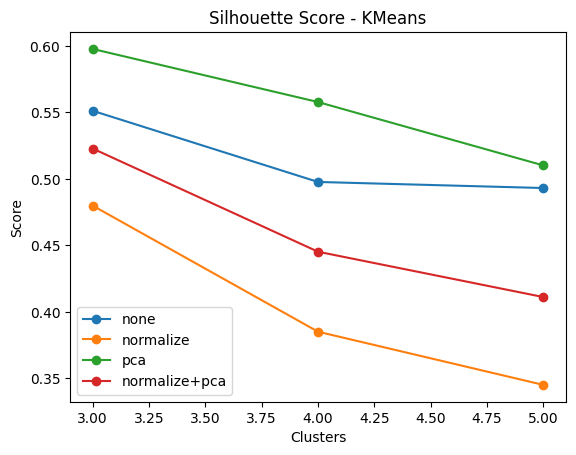

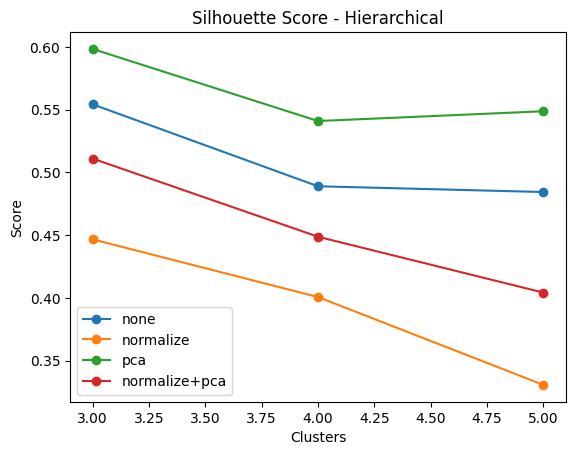

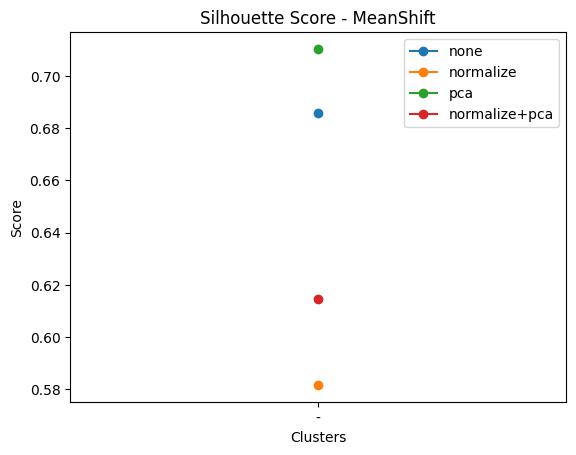

In [2]:
import matplotlib.pyplot as plt

# Plot Silhouette scores
for algo in df["Algorithm"].unique():
    subset = df[df["Algorithm"] == algo]

    plt.figure()
    for prep in subset["Preprocessing"].unique():
        temp = subset[subset["Preprocessing"] == prep]
        plt.plot(temp["Clusters"], temp["Silhouette"], marker='o', label=prep)

    plt.title(f"Silhouette Score - {algo}")
    plt.xlabel("Clusters")
    plt.ylabel("Score")
    plt.legend()
    plt.show()